# Advertising Sales Prediction — Linear & Polynomial Regression
## Overview

This project builds and evaluates regression models to predict product sales based on advertising spend across three channels: TV, radio, and newspaper.

The goal is to quantify the relationship between marketing investment and sales outcomes, and determine which model best captures the underlying patterns in the data. The analysis progresses from a baseline multiple linear regression through polynomial feature expansion, residual diagnostics, and Ridge regularization to guard against overfitting.

### Dataset

The [Advertising dataset](https://www.kaggle.com/datasets/ashydv/advertising-dataset) contains 200 observations across four variables: TV spend, radio spend, newspaper spend, and sales — all in thousands of dollars/units.

### Workflow

1. Exploratory data analysis — visualizing spend-vs-sales relationships per channel
2. Multiple linear regression — baseline model with all three features
3. Residual diagnostics — checking model assumptions
4. Polynomial regression — capturing non-linear interactions between features
5. Degree selection — using train/test RMSE to choose optimal polynomial degree
6. Model persistence — saving the final model with `joblib`
7. Ridge regularization — penalizing complexity to reduce overfitting

### Stack

Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn, SciPy, joblib

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


Text(0.5, 1.0, 'NewsPaper spend')

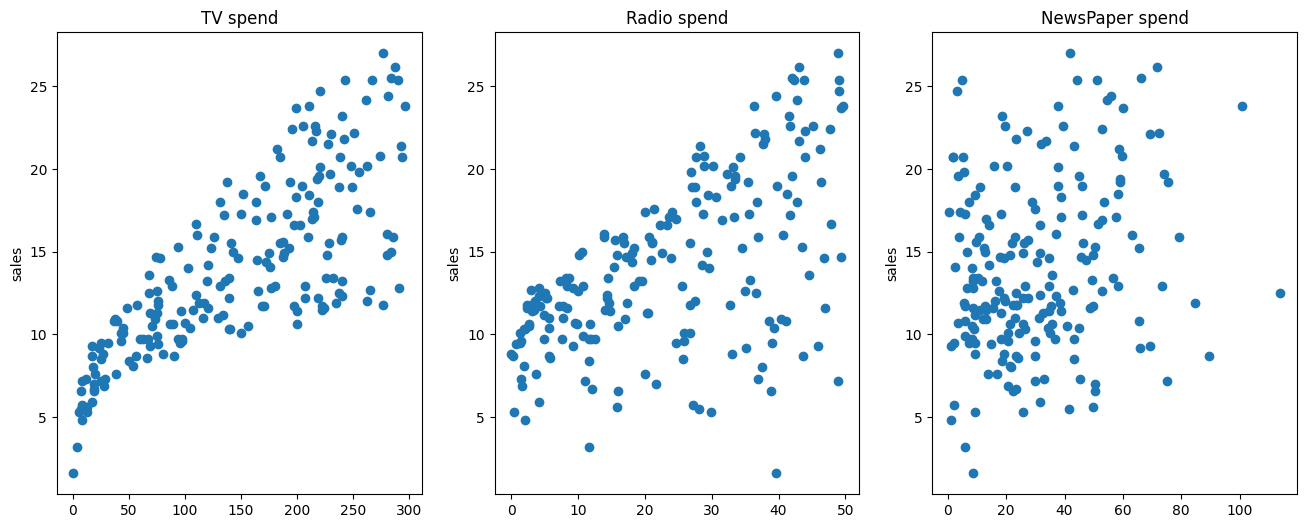

In [6]:
fig,axes= plt.subplots(nrows=1,ncols=3,figsize=(16,6))
axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel('sales')
axes[0].set_title("TV spend")


axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_ylabel('sales')
axes[1].set_title("Radio spend")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_ylabel('sales')
axes[2].set_title("NewsPaper spend")

In [7]:
x= df.drop('sales',axis=1)
y= df['sales']

In [8]:
x

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [9]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
x_train

,TV,radio,newspaper
169,284.3,10.6,6.4
97,184.9,21.0,22.0
31,112.9,17.4,38.6
12,23.8,35.1,65.9
35,290.7,4.1,8.5
...,...,...,...
106,25.0,11.0,29.7
14,204.1,32.9,46.0
92,217.7,33.5,59.0
179,165.6,10.0,17.6


In [16]:
x_test

,TV,radio,newspaper
95,163.3,31.6,52.9
15,195.4,47.7,52.9
30,292.9,28.3,43.2
158,11.7,36.9,45.2
128,220.3,49.0,3.2
115,75.1,35.0,52.7
69,216.8,43.9,27.2
170,50.0,11.6,18.4
174,222.4,3.4,13.1
45,175.1,22.5,31.5


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
model = LinearRegression()

In [20]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
model.coef_

array([0.04405928, 0.1992875 , 0.00688245])

In [22]:
test_pred= model.predict(x_test)

In [23]:
y_test

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    11.5
45     14.9
66      9.5
182     8.7
165    11.9
78      5.3
186    10.3
177    11.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65      9.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      10.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
79     11.0
197    12.8
38     10.1
24      9.7
122    11.6
195     7.6
29     10.5
19     14.6
143    10.4
86     12.0
114    14.6
173    11.7
5       7.2
126     6.6
117     9.4
73     11.0
140    10.9
98     25.4
172     7.6
96     11.7
Name: sales, dtype: float64

In [24]:
test_pred

array([16.5653963 , 21.18822792, 21.55107058, 10.88923816, 22.20231988,
       13.35556872, 21.19692502,  7.35028523, 13.27547079, 15.12449511,
        9.01443026,  6.52542825, 14.30205991,  8.97026042,  9.45679576,
       12.00454351,  8.91549403, 16.15619251, 10.29582883, 18.72473553,
       19.76821818, 13.77469028, 12.49638908, 21.53501762,  7.60860741,
        5.6119801 , 20.91759483, 11.80627665,  9.08076637,  8.51412012,
       12.17604891,  9.9691939 , 21.73008956, 12.77770578, 18.1011362 ,
       20.07590796, 14.26202556, 20.93826535, 10.83938827,  4.38190607,
        9.51332406, 12.40486324, 10.17045434,  8.09081363, 13.16388427,
        5.2243552 ,  9.28893833, 14.09330719,  8.69024497, 11.66119763,
       15.71848432, 11.63156862, 13.35360735, 11.1531472 ,  6.33636845,
        9.76157954,  9.4195714 , 24.25516546,  7.69519137, 12.15317572])

In [25]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [26]:
MAE= mean_absolute_error(y_test,test_pred)
MAE

1.5116692224549086

In [27]:
MSE = mean_squared_error(y_test,test_pred)
MSE

3.79679723671522

In [28]:
RMSE= np.sqrt(mean_squared_error(y_test,test_pred))
RMSE

np.float64(1.9485372043446387)

In [29]:
test_residuals= y_test- test_pred
test_residuals

95     0.334604
15     1.211772
30    -0.151071
158   -3.589238
128    2.497680
115   -0.755569
69     1.103075
170    1.049715
174   -1.775471
45    -0.224495
66     0.485570
182    2.174572
165   -2.402060
78    -3.670260
186    0.843204
177   -0.304544
56    -3.415494
152    0.443807
82     1.004171
68     0.175264
124   -0.068218
16    -1.274690
148   -1.596389
93     0.664982
65     1.691393
60     2.488020
84     0.782405
67     1.593723
125    1.519234
132   -2.814120
9     -1.576049
18     1.330806
55     1.969910
75    -4.077706
150   -2.001136
104    0.624092
135   -2.662026
137   -0.138265
164    1.060612
76     2.518094
79     1.486676
197    0.395137
38    -0.070454
24     1.609186
122   -1.563884
195    2.375645
29     1.211062
19     0.506693
143    1.709755
86     0.338802
114   -1.118484
173    0.068431
5     -6.153607
126   -4.553147
117    3.063632
73     1.238420
140    1.480429
98     1.144835
172   -0.095191
96    -0.453176
Name: sales, dtype: float64

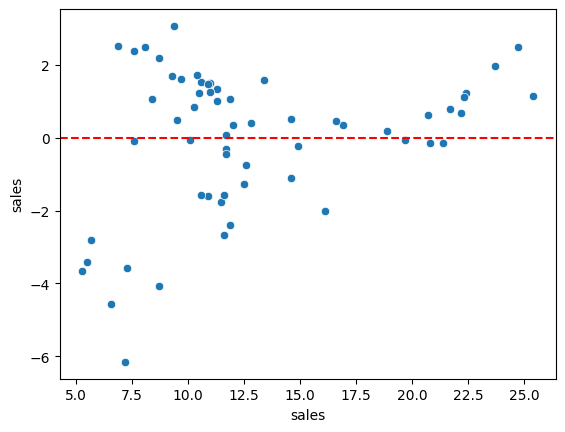

In [30]:
sns.scatterplot(x=y_test,y= test_residuals)
plt.axhline(y=0,color='r',ls='--')

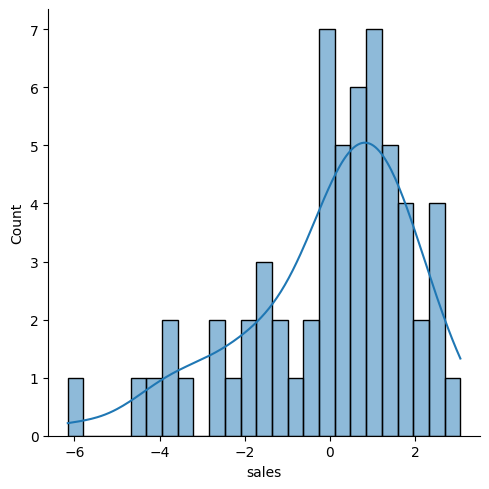

In [31]:
sns.displot(test_residuals,bins=25,kde=True)

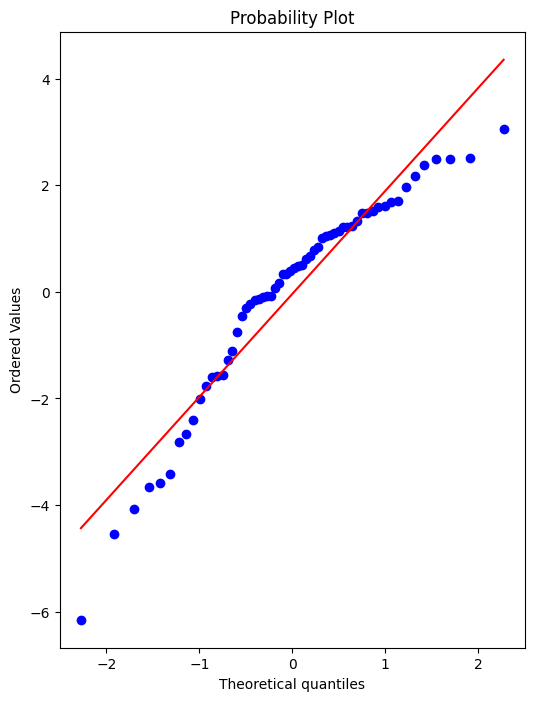

In [32]:
import scipy as sp

fig,axes= plt.subplots(figsize=(6,8),dpi=100)
_ = sp.stats.probplot(test_residuals,plot=axes)


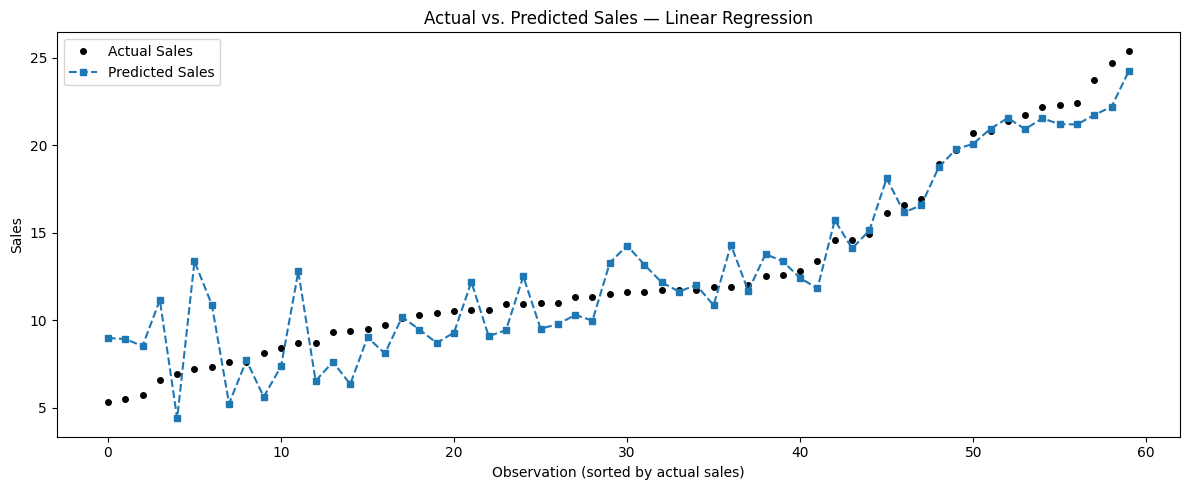

In [33]:
# Sorted actual vs. predicted — visual check of linear model fit
sorted_idx = np.argsort(y_test.values)
plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test)), y_test.values[sorted_idx], 'ko', markersize=4, label='Actual Sales')
plt.plot(range(len(y_test)), test_pred[sorted_idx], 's--', markersize=4, label='Predicted Sales')
plt.xlabel('Observation (sorted by actual sales)')
plt.ylabel('Sales')
plt.title('Actual vs. Predicted Sales — Linear Regression')
plt.legend()
plt.tight_layout()

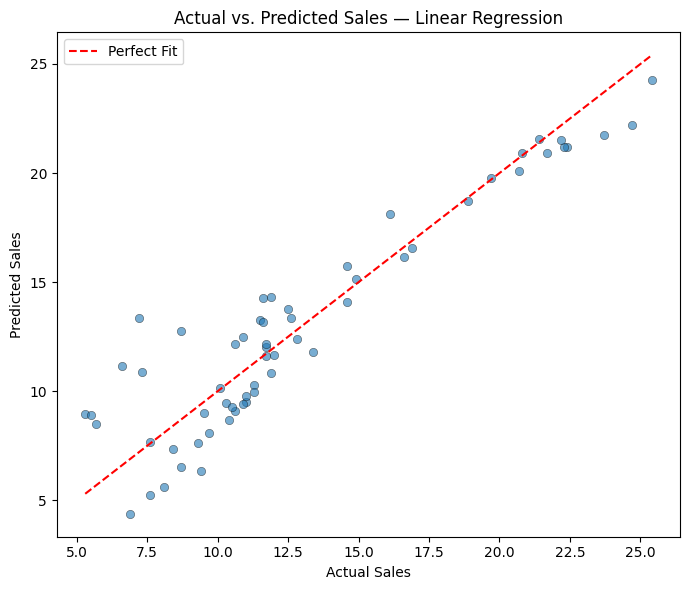

In [34]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales — Linear Regression')
plt.legend()
plt.tight_layout()

---
## Part Two: Polynomial Regression

The linear model captures the overall trend but may miss non-linear interactions between channels — for example, the combined effect of TV and radio spend on sales tends to amplify beyond what either channel predicts alone.

Polynomial feature expansion generates interaction terms and higher-order features from the original three columns, allowing a linear model to fit curved and interactive relationships. A `PolynomialFeatures(degree=2)` transformer expands the 3-feature input into 9 features: original terms, squared terms, and all pairwise interaction terms.

---

In [35]:
from sklearn.preprocessing import PolynomialFeatures

In [36]:
poly_converter= PolynomialFeatures(degree=2,include_bias = False)

In [37]:
# fit_transform fits the transformer on x and returns the expanded feature matrix

In [38]:
poly_features= poly_converter.fit_transform(x)

In [39]:
x.shape

(200, 3)

In [40]:
poly_converter.transform(x).shape

(200, 9)

In [41]:
x.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [42]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [43]:
X_train,X_test,Y_train,Y_test= train_test_split(poly_features,y,test_size=0.3,random_state=101)

In [44]:
X_train

array([[1.93200e+02, 1.84000e+01, 6.57000e+01, ..., 3.38560e+02,
        1.20888e+03, 4.31649e+03],
       [2.87600e+02, 4.30000e+01, 7.18000e+01, ..., 1.84900e+03,
        3.08740e+03, 5.15524e+03],
       [8.02000e+01, 0.00000e+00, 9.20000e+00, ..., 0.00000e+00,
        0.00000e+00, 8.46400e+01],
       ...,
       [2.39800e+02, 4.10000e+00, 3.69000e+01, ..., 1.68100e+01,
        1.51290e+02, 1.36161e+03],
       [2.14700e+02, 2.40000e+01, 4.00000e+00, ..., 5.76000e+02,
        9.60000e+01, 1.60000e+01],
       [1.63300e+02, 3.16000e+01, 5.29000e+01, ..., 9.98560e+02,
        1.67164e+03, 2.79841e+03]], shape=(140, 9))

In [45]:
model1 = LinearRegression()

In [46]:
model1.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
pred= model1.predict(X_test)

In [48]:
MAE= mean_absolute_error(Y_test,pred)
MAE

0.48967980448035886

In [49]:
MSE = mean_squared_error(Y_test,pred)
MSE

0.44175055104033895

In [50]:
RMSE= np.sqrt(mean_squared_error(Y_test,pred))
RMSE

np.float64(0.6646431757269)

In [51]:
test_res= Y_test- pred
test_res

37     0.751438
109    0.465197
31    -0.419282
89    -0.062863
66     1.597891
119   -0.341438
54     0.066273
74    -0.500927
145   -0.268890
142   -0.025518
148    1.453855
112    0.000646
174   -0.555135
55     0.307460
141   -0.475084
149    0.943737
25    -0.116373
34     0.218504
170   -0.046040
39    -0.155881
172    0.549297
153   -0.358542
175   -0.267164
61    -0.386893
65     0.268206
50    -0.410702
42     0.273699
129    0.506094
179   -0.147952
2      0.656593
12     0.537058
133   -0.600474
90     0.263262
22    -1.246391
41    -1.179394
32     0.123406
125    0.257579
196    0.034296
158   -0.133479
180   -0.535613
16    -0.157310
186   -0.354599
144    0.190285
121   -0.461990
80     0.417750
18     1.026687
78    -0.855733
48    -0.708934
4     -0.460929
15    -0.318393
1     -0.003897
43    -0.316227
102    0.563778
164    0.027632
9     -1.084636
155   -2.422177
36     0.362211
190    1.264923
33     0.020734
45    -0.853436
Name: sales, dtype: float64

Text(0.5, 1.0, 'Polynomial Model — Residual Distribution')

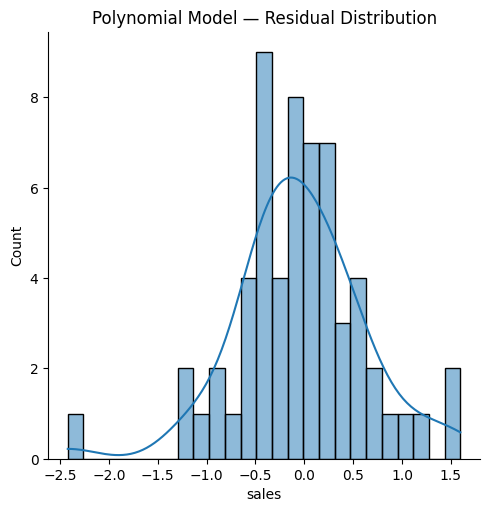

In [52]:
sns.displot(test_res, bins=25, kde=True)
plt.title('Polynomial Model — Residual Distribution')

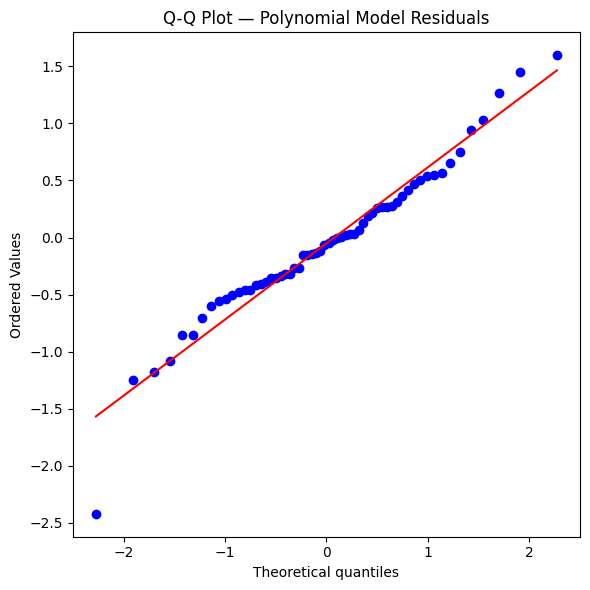

In [53]:
import scipy as sp

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
_ = sp.stats.probplot(test_res, plot=ax)
ax.set_title('Q-Q Plot — Polynomial Model Residuals')
plt.tight_layout()

In [54]:
from sklearn.metrics import r2_score

r2_linear = r2_score(y_test, test_pred)
r2_poly   = r2_score(Y_test, pred)

print(f"Linear Regression  R² : {r2_linear:.4f}")
print(f"Polynomial (deg=2) R² : {r2_poly:.4f}")

Linear Regression  R² : 0.8609
Polynomial (deg=2) R² : 0.9844


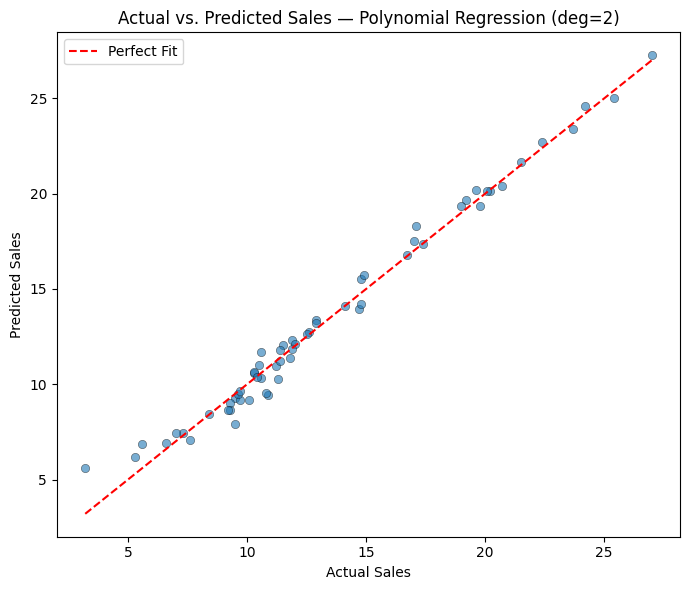

In [55]:
plt.figure(figsize=(7, 6))
plt.scatter(Y_test, pred, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales — Polynomial Regression (deg=2)')
plt.legend()
plt.tight_layout()

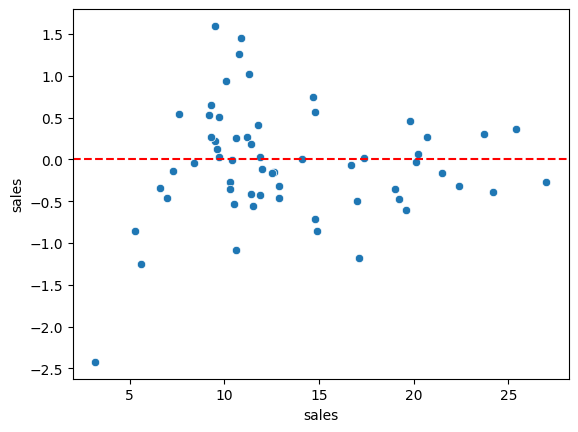

In [56]:
sns.scatterplot(x=Y_test,y= test_res)
plt.axhline(y=0,color='r',ls='--')

In [57]:
# Sweep polynomial degrees 1–9 to identify the optimal degree via train/test RMSE

In [58]:
# Strategy: for each degree, fit a polynomial model and record RMSE on both
# train and test sets. Overfitting shows up when test RMSE rises while train RMSE keeps falling.

In [59]:
train_rmse_errors= []
test_rmse_errors=[]

for d in range(1,10):
    poly_conv= PolynomialFeatures(degree=d,include_bias=False)
    poly_features= poly_conv.fit_transform(x)
    X_train,X_test,Y_train,Y_test= train_test_split(poly_features,y,test_size=0.3,random_state=101)
    model= LinearRegression()
    model.fit(X_train,Y_train)
    
    train_pred= model.predict(X_train)
    test_pred= model.predict(X_test)
    
    train_rmse= np.sqrt(mean_squared_error(Y_train,train_pred))
    test_rmse= np.sqrt(mean_squared_error(Y_test,test_pred))
    
    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)
    
    
    
    

In [60]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923820358),
 np.float64(0.20953728417844544),
 np.float64(0.22046859203477034),
 np.float64(0.2715007492459394),
 np.float64(0.5132041534764287)]

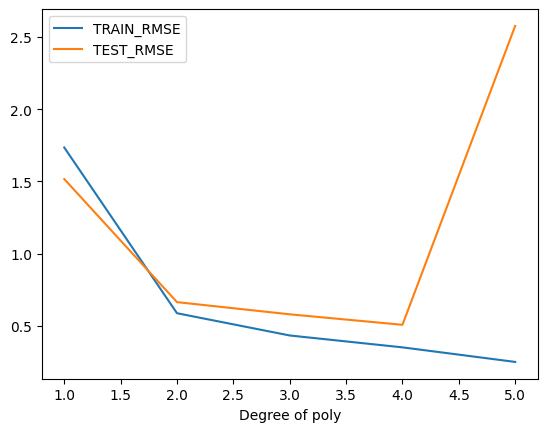

In [61]:
plt.plot(range(1,6),train_rmse_errors[:5],label= 'TRAIN_RMSE')
plt.plot(range(1,6),test_rmse_errors[:5],label= 'TEST_RMSE')
plt.xlabel('Degree of poly')
plt.legend()

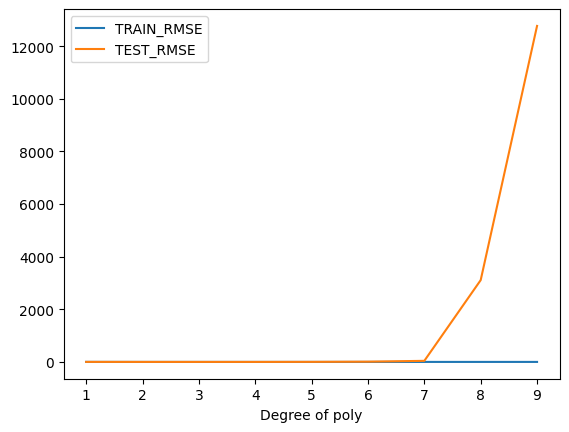

In [62]:
plt.plot(range(1,10),train_rmse_errors,label= 'TRAIN_RMSE')
plt.plot(range(1,10),test_rmse_errors,label= 'TEST_RMSE')
plt.xlabel('Degree of poly')
plt.legend()

In [63]:
final_poly_converter= PolynomialFeatures(degree=3,include_bias= False)


In [64]:
final_model= LinearRegression()

In [65]:
full_converted_x= final_poly_converter.fit_transform(x)
final_model.fit(full_converted_x,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
from joblib import dump,load

In [67]:
dump(final_model,'final_poly_model.joblib')

['final_poly_model.joblib']

In [68]:
dump(final_poly_converter,'final_converter.joblib')

['final_converter.joblib']

In [69]:
loaded_converter = load('final_converter.joblib')

In [70]:
loaded_model= load('final_poly_model.joblib')

In [71]:
campaign = [[149,22,12]]

In [72]:
transformed_data= loaded_converter.fit_transform(campaign)

In [73]:
loaded_model.predict(transformed_data)

array([14.64501014])

---
## Part Three: Ridge Regularization

Higher-degree polynomial models risk overfitting — memorizing training noise rather than learning the true signal. Ridge regression addresses this by adding an L2 penalty term to the loss function, shrinking coefficients toward zero and reducing variance at the cost of a small increase in bias.

The `alpha` hyperparameter controls the strength of regularization. A larger alpha imposes stronger shrinkage. Here we evaluate Ridge on the same polynomial-expanded features used in Part Two and compare error metrics to the unregularized model.

In [74]:
# Re-create degree-3 polynomial features for Ridge regularization fitting

In [75]:
poly_converter= PolynomialFeatures(degree=3,include_bias = False)

In [76]:
from sklearn.linear_model import  Ridge

In [77]:
# Ridge key parameters:
#   alpha  — regularization strength; higher alpha = stronger shrinkage (default: 1.0)
#   solver — algorithm: 'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'
#   fit_intercept — whether to center the data before fitting (default: True)
print("Ridge minimizes: ||y - Xw||² + alpha * ||w||²")

Ridge minimizes: ||y - Xw||² + alpha * ||w||²


In [78]:
ridge_model = Ridge(alpha=10)

In [79]:
ridge_model.fit(X_train,Y_train)

C:\Users\Kaushal Desai\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [80]:
test_p= ridge_model.predict(X_test)

In [81]:
MAE= mean_absolute_error(Y_test,test_p)
MAE

5.15707448666406

In [82]:
MSE = mean_squared_error(Y_test,test_p)
MSE

424.1490485163785

In [83]:
RMSE= np.sqrt(MSE)
RMSE

np.float64(20.594879181883503)